ARTI308 - Machine Learning

# ARTI406 - Assignment 2
## Netflix Dataset Analysis
### Student Name: Aalya Hussain Almusabeh
### Student ID: 2230003073

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("netflix_titles.csv")
df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

- The Netflix dataset was loaded using Pandas, and the first five rows were displayed to understand the structure of the data.

## 2. Data Quality Assessment

### 2.1 Check Data Types

Data types were checked to ensure that each column has the correct format.

Examples:
- `release_year` should be numeric
- `date_added` should be datetime
- `title`, `director`, and `country` should be categorical/text values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       999 non-null    object
 1   type          999 non-null    object
 2   title         999 non-null    object
 3   director      684 non-null    object
 4   cast          902 non-null    object
 5   country       693 non-null    object
 6   date_added    999 non-null    object
 7   release_year  999 non-null    int64 
 8   rating        999 non-null    object
 9   duration      999 non-null    object
 10  listed_in     999 non-null    object
 11  description   999 non-null    object
dtypes: int64(1), object(11)
memory usage: 93.8+ KB


- The dataset information was checked to identify data types and missing values in each column.

In [7]:
df.duplicated().sum()

np.int64(0)

- Duplicate records were checked to ensure data quality and consistency.

### 2.2 Convert Incorrect Data Types

The `date_added` column was converted to datetime format to make it easier for analysis and preprocessing tasks.

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'])

df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

- The `date_added` column was converted from object type to datetime format for better date handling and analysis.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [9]:
df.isna().sum()

show_id           0
type              0
title             0
director        315
cast             97
country         306
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

- The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

- Missing values were identified in several columns such as director, cast, and country.

### Strategy 1 — Replace with "Unknown"

In [29]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

C:\Users\aalya\AppData\Local\Temp\ipykernel_18496\3745680589.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\aalya\AppData\Local\Temp\ipykernel_18496\3745680589.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

### Why?
- Missing values were replaced with "Unknown" to preserve the dataset size without introducing potentially misleading values.

In [34]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

- The dataset was checked again after handling missing values to confirm that the missing data was removed.

### Strategy 2 — Forward Fill

In [35]:
df.fillna(method='ffill', inplace=True)

C:\Users\aalya\AppData\Local\Temp\ipykernel_18496\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


### Why?
- Forward fill was used to replace missing values using the previous valid observation in the dataset.

## 4. Handling Outliers


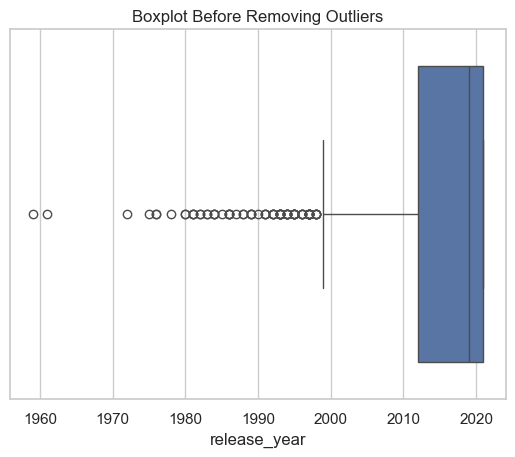

In [44]:
sns.boxplot(x=df['release_year'])
plt.title("Boxplot Before Removing Outliers")
plt.show()

### Before
- A boxplot was used to visually detect outliers in the release_year column before applying the IQR method.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [43]:
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

1998.5 2034.5


- The IQR method was used to calculate the lower and upper boundaries for detecting outliers in the release_year column.

### Remove Outliers
We remove values outside the acceptable range.

In [46]:
df = df[(df['release_year'] >= lower) & (df['release_year'] <= upper)]

df.shape

(922, 12)

- The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.


- Rows containing outliers outside the acceptable range were removed from the dataset.

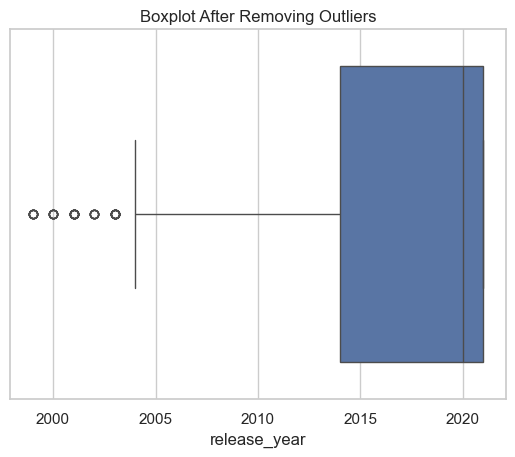

In [48]:
sns.boxplot(x=df['release_year'])
plt.title("Boxplot After Removing Outliers")
plt.show()

### After
- The boxplot after applying the IQR method shows that the extreme values were successfully handled.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

In [60]:
df[['release_year']].head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


### 1- Min-Max Normalization

In [62]:
minmax = MinMaxScaler()

minmax_scaled = minmax.fit_transform(num_data)

minmax_df = pd.DataFrame(minmax_scaled, columns=['release_year'])

minmax_df.head()

,release_year
0,0.954545
1,1.000000
2,1.000000
3,1.000000
4,1.000000


- After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

- The smallest value in each feature becomes 0, and the largest becomes 1. All other values are proportionally mapped between these two limits.

### 2- Z-Score Normalization

In [70]:
zscore = StandardScaler()

zscore_scaled = zscore.fit_transform(num_data)

zscore_df = pd.DataFrame(zscore_scaled, columns=['release_year'])

zscore_df.head()

,release_year
0,0.540988
1,0.715451
2,0.715451
3,0.715451
4,0.715451


### Explanation:
Z-score normalization was used to standardize the data with a mean of 0 and standard deviation of 1.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

In [65]:
df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})

C:\Users\aalya\AppData\Local\Temp\ipykernel_18496\3682432202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})


- The categorical type column was encoded into numerical values to make it suitable for PCA.

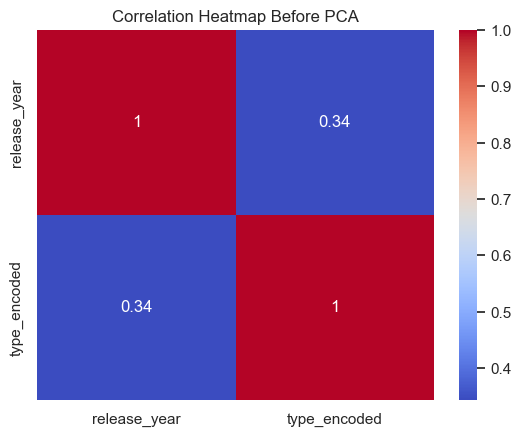

In [68]:
features = df[['release_year', 'type_encoded']]

sns.heatmap(features.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap Before PCA")

plt.show()

- A correlation heatmap was created to examine the relationship between numerical features before applying PCA.

## 6. Data Reduction – Principal Component Analysis (PCA)

In [66]:
features = df[['release_year', 'type_encoded']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA()

pca_result = pca.fit_transform(scaled_features)

print(pca.explained_variance_ratio_)

[0.67195094 0.32804906]


### Explanation:
- PCA was applied to reduce dimensionality and analyze how much variance is explained by each principal component.

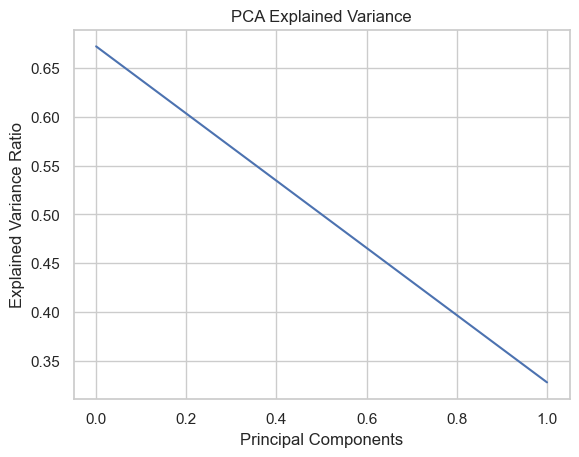

In [72]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

This plot shows the explained variance ratio for each principal component after applying PCA.


- The horizontal axis represents Principal Components.
- The vertical axis represents the amount of variance explained by each component.
